In [24]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.rate_utils import GetRates
from src.assets.bond import Bond
from src.assets.portfolio import BondPortfolio
from src.assets.pricing import price_bond
from src.liabilities.deposit_model import DepositModel
from src.liabilities.cashflow_generator import present_value
from src.rates.hull_white import HullWhite
from src.risk.monte_carlo import MonteCarlo
from src.risk.stress_testing import StressTesting

from src.data_loader.synthetic_balance_sheet import load_assets, load_liabilities
from src.risk.monte_carlo import MonteCarlo

In [25]:
# loading yield curves
df = pd.read_csv(
    "../data/processed/cleaned_yield_curve_fred.csv",
    index_col = 'date',
    parse_dates = True
)

# extracting latest yield curve
curve = GetRates().get_latest_curve(df)

# extracting initial short rate
r0 = GetRates().get_short_rate(curve)

# building balance sheet components
### -- ASSETS --
bonds = [
    Bond(face_value=1000, coupon_rate=0.02, maturity=3),
    Bond(face_value=1000, coupon_rate=0.03, maturity=5),
    Bond(face_value=1000, coupon_rate=0.04, maturity=10)
]

bond_portfolio = BondPortfolio(bonds)

### -- LIABILITIES --
deposit_model = DepositModel(initial_amount=11700, decay_rate=0.965)

In [26]:
# loading PCA outputs
pca_factors = pd.read_csv(
    '../data/processed/pca_factors.csv',
    index_col = 0
)

eigenvectors = np.load('../data/processed/pca_eigenvectors.npy')
mean_curve = np.load('../data/processed/pca_mean_curve.npy')

# maturitiesin years
maturities = np.array([int(col.rstrip('Y')) for col in df.columns])

# load synthetic balance sheet
assets = load_assets()
liabilities = load_liabilities()

In [27]:
# running PCA ALM Monte Carlo
alm_mc = MonteCarlo(
    portfolio = bond_portfolio,
    deposit_model = deposit_model,
    pricing_function = price_bond,
    liability_pv_function = present_value
)

results = alm_mc.run_simulation_pca(
    assets = assets,
    liabilities = liabilities,
    pca_factors = pca_factors,
    eigenvectors = eigenvectors,
    mean_curve = mean_curve,
    maturities = maturities,
    n_sims = 1000,
    n_steps = 120 # 10-year monthly steps
)

asset_values = results['asset_values']
liability_values = results['liability_values']
equity = results['equity']
funding_ratio = results['funding_ratio']

print(f'Underfunding probability: {results['underfunding_probability']}')

Underfunding probability: 1.0


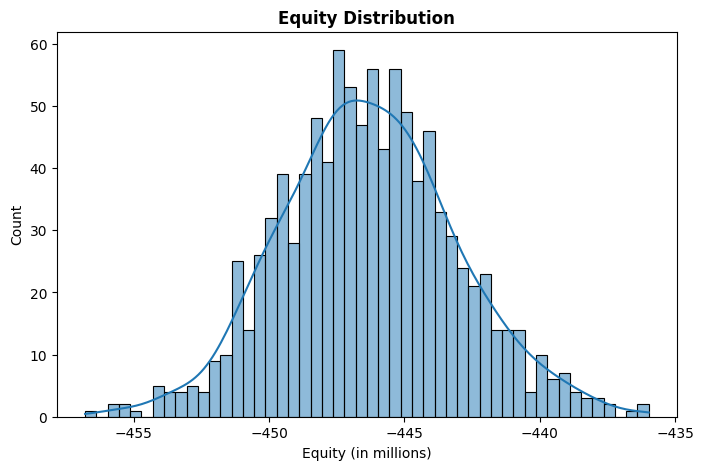

In [ ]:
# equity distribution
plt.figure(figsize=(8, 5))
sns.histplot(
    equity, 
    bins = 50, 
    kde=True
)
plt.title('Equity Distribution', fontweight = 'bold')
plt.xlabel('Equity (in millions)')
plt.show()

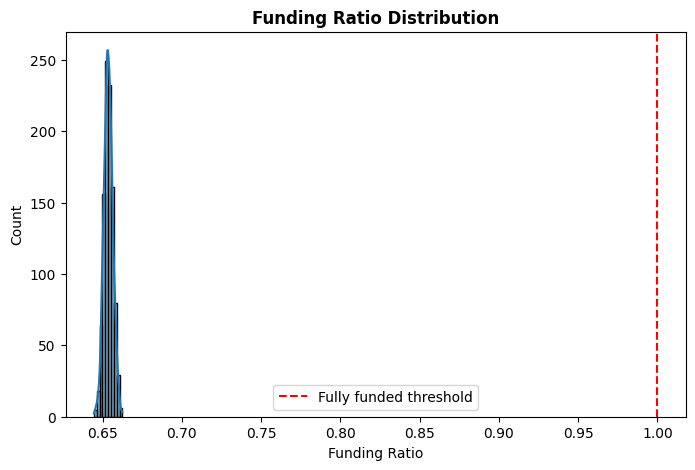

In [33]:
# funding ration distribution
plt.figure(figsize=(8, 5))
sns.histplot(
    funding_ratio, 
    bins = 10, 
    kde=True
)

plt.axvline(
    1, 
    color = 'red', 
    linestyle = '--',
    label = 'Fully funded threshold'
)
plt.title('Funding Ratio Distribution', fontweight = 'bold')
plt.xlabel('Funding Ratio')
plt.legend()
plt.show()

Funding Ratio VaR 95%: 0.649
Funding Ratio CVaR 95%: 0.648


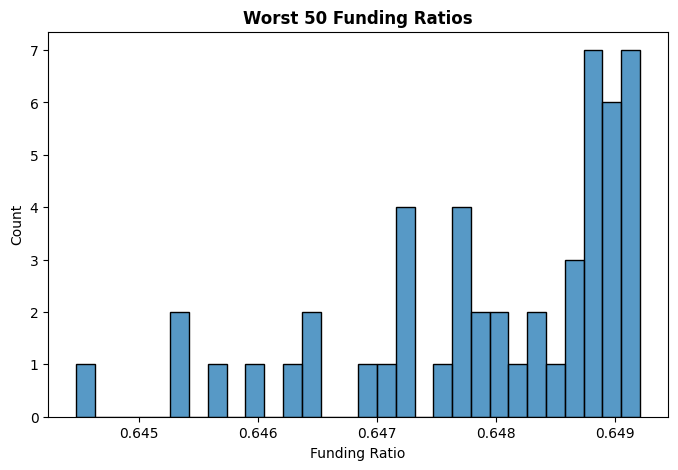

In [37]:
# tail risk (VaR & CVaR)
def var_cvar(x, alpha = 0.95):
    var = np.percentile(x, (1-alpha) * 100)
    cvar = x[x <= var].mean()
    return var, cvar

var95, cvar95 = var_cvar(funding_ratio)

print(f'Funding Ratio VaR 95%: {var95:.3f}')
print(f'Funding Ratio CVaR 95%: {cvar95:.3f}')

# plotting worst 50 funding ratio scenarios
worst_idx = np.argsort(funding_ratio)[:50]

plt.figure(figsize=(8, 5))
sns.histplot(
    funding_ratio[worst_idx], 
    bins = 30,
    kde=False
)
plt.title('Worst 50 Funding Ratios', fontweight = 'bold')
plt.xlabel('Funding Ratio')
plt.show()